<a href="https://colab.research.google.com/github/mareegpost/xal-forecast/blob/main/goat_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1: Setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/goat_prices.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (150, 7)


,goat_id,age_months,weight_kg,health_score,region,season,price_usd
0,1,8,32.8,6,South,Rainy,94.46
1,2,22,50.0,4,North,Rainy,110.00
2,3,21,41.1,9,South,Dry,109.66
3,4,12,31.3,9,North,Dry,104.64
4,5,15,37.5,9,North,Rainy,110.00


count    150.000000
mean     102.203067
std        8.223286
min       80.220000
25%       96.202500
50%      103.895000
75%      110.000000
max      110.000000
Name: price_usd, dtype: float64


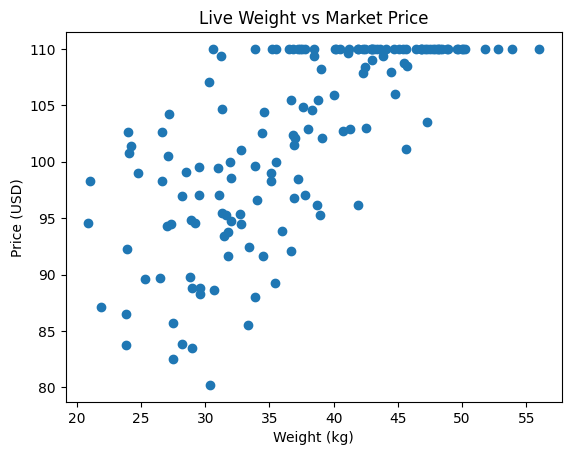

In [ ]:
# CELL 3: Explore
print(df['price_usd'].describe())
plt.scatter(df['weight_kg'], df['price_usd'])
plt.xlabel('Weight (kg)'); plt.ylabel('Price (USD)')
plt.title('Live Weight vs Market Price'); plt.show()


In [ ]:
# CELL 4: Prepare
X = df[['age_months', 'weight_kg', 'health_score']]
y = df['price_usd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# CELL 5: Train
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Weight importance: {model.coef_[1]:.2f} USD per kg")


Weight importance: 0.25 USD per kg


In [ ]:
# CELL 6: Evaluate
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f"RMSE: ${rmse:.2f}, R²: {r2:.2%}")


RMSE: $4.72, R²: 70.58%


In [ ]:
# CELL 7: Predict New
new_goat = [[10, 38, 8]]
predicted = model.predict(new_goat)[0]
print(f"Predicted price: ${predicted:.2f}")

Predicted price: $100.45


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
